In [1]:
# convert .json to pd.dataframe
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# UDFs functions
from src.functions import create_stocks_dataframe
from src.prepare_data import prepare_stock_data
from src.yearwise_price_change_summary import get_historical_prices
from src.return_calculate import calculate_returns
from src.price_status import calculate_price_status

In [2]:
from src.load_config import load_json_config
local_config = load_json_config("config/local.json")
local_config["database_path"]

'C:/Users/rocke/OneDrive/1. daily_deliverables/1. master_folder/investment_strategy/project_automation/stock_db/data/stocks.duckdb'

In [3]:
from src.duck_db_utils import get_conn
conn = get_conn()
conn.execute("SELECT * FROM stocks LIMIT 5").fetchall()

[(1, 'RELIANCE', 'NSE', datetime.datetime(2026, 8, 7, 20, 29, 44, 51000)),
 (2, 'SAPPHIRE', 'NSE', datetime.datetime(2026, 8, 9, 13, 19, 9, 485000)),
 (3, 'LLOYDSENGG', 'NSE', datetime.datetime(2026, 8, 9, 13, 19, 15, 585000)),
 (4, 'TAALTECH', 'NSE', datetime.datetime(2026, 8, 9, 13, 19, 21, 269000))]

In [4]:
from src.duck_db_utils import get_db_table_names, get_conn
conn = get_conn()
get_db_table_names(conn)

['refresh_log', 'stock_data', 'stocks', 'todays_data']

In [6]:
import importlib
import src.duck_db_utils as duck_db_utils
importlib.reload(duck_db_utils)
from src.duck_db_utils import get_table_data

# Individual stock analysis example

In [7]:
# Individual stock analysis example
stock_name = "Reliance Industries Limited"
stock_data = get_table_data(conn, "stock_data")
stock_data = stock_data[stock_data["stock_name"] == stock_name]
stock_metadata = {
    'stock_name': stock_name
}

In [13]:
todays_data = get_table_data(conn, "todays_data")
todays_data.head(2)
# todays_data = todays_data[todays_data["stock_name"] == stock_name]

,stock_id,stock_name,exchange,symbol,quote_date,open,high,low,close,adj_close,...,current_price,pe_ratio_trailing,pe_ratio_forward,beta_5y_monthly,market_cap,fifty_two_week_high,fifty_two_week_low,company_name,sector,industry
0,1,Reliance Industries Limited,NSE,RELIANCE,2026-08-07,1320.0,1337.000000,1316.599976,1334.800049,1334.800049,...,1334.80,24.154905,18.663729,0.157,1.806315e+13,1611.8,1249.8,Reliance Industries Limited,Energy,Oil & Gas Refining & Marketing
1,3,Lloyds Engineering Works Limited,NSE,LLOYDSENGG,2026-08-07,91.0,97.599998,90.750000,96.879997,96.879997,...,96.88,65.020134,NaN,1.198,1.432511e+11,97.6,37.4,Lloyds Engineering Works Limited,Industrials,Specialty Industrial Machinery


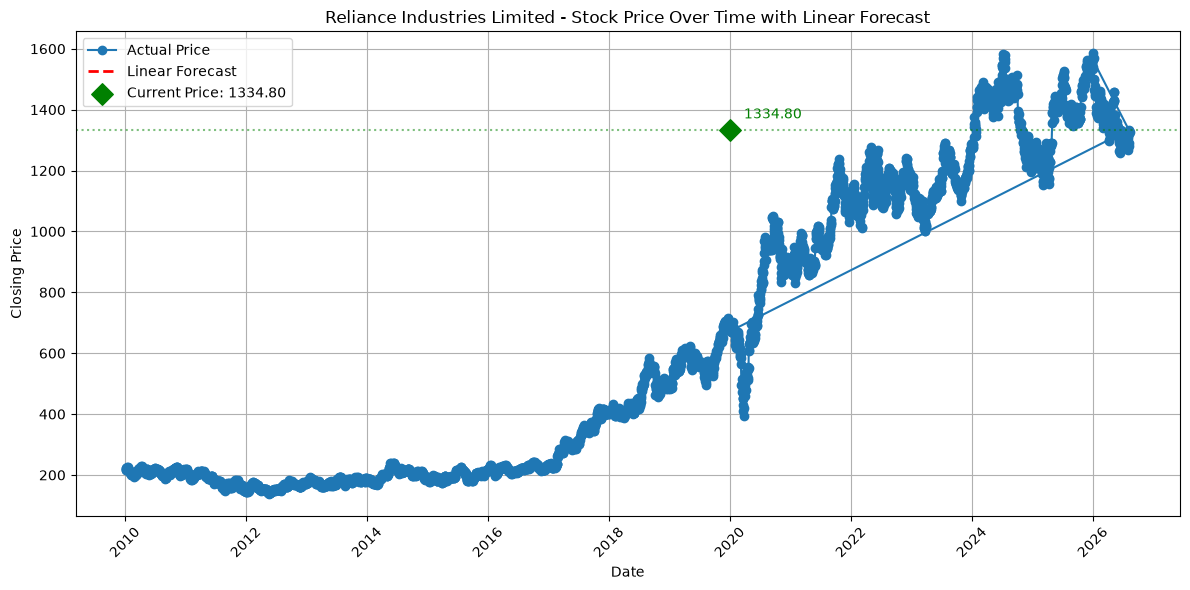

In [14]:
# Convert dates to numeric values for linear regression
x = np.arange(len(stock_data))
y = stock_data['adj_close'].values

# Fit a linear regression line
coefficients = np.polyfit(x, y, 1)
linear_fit = np.poly1d(coefficients)
forecast_line = linear_fit(x)

# Get current price for selected stock from todays_data
cp = todays_data.loc[todays_data['stock_name'] == stock_name, 'current_price']
current_price = float(cp.iloc[0]) if not cp.empty else np.nan

# Use latest available trade date as x-position for current price marker
latest_trade_date = stock_data['trade_date'].iloc[-1]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(stock_data['trade_date'], stock_data['adj_close'], marker='o', label='Actual Price')
plt.plot(stock_data['trade_date'], forecast_line, color='red', linestyle='--', linewidth=2, label='Linear Forecast')

# Mark current price
if not np.isnan(current_price):
    plt.scatter([latest_trade_date], [current_price], color='green', s=120, marker='D',
                zorder=5, label=f'Current Price: {current_price:.2f}')
    plt.axhline(current_price, color='green', linestyle=':', alpha=0.5)
    plt.annotate(f'{current_price:.2f}',
                 xy=(latest_trade_date, current_price),
                 xytext=(10, 8), textcoords='offset points',
                 color='green')

plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title(f'{stock_name} - Stock Price Over Time with Linear Forecast')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pandas as pd

def create_stock_forecast_chart(stock_data, todays_data, stock_name):
    """
    Create an enhanced stock price forecast chart with multiple analytical insights.
    Automatically handles data sorting and NaN values.
    """
    
    # Create a clean copy
    clean_data = stock_data[['trade_date', 'adj_close']].copy()
    
    # Sort by date (oldest to newest) - CRITICAL FIX
    clean_data = clean_data.sort_values('trade_date', ascending=True).reset_index(drop=True)
    
    # Remove any NaN values
    clean_data = clean_data.dropna(subset=['adj_close', 'trade_date'])
    
    if len(clean_data) == 0:
        print("❌ Error: No valid data available after cleaning")
        return None, None, None
    
    print(f"✅ Data cleaned: {len(clean_data)} valid data points")
    print(f"📅 Date range: {clean_data['trade_date'].iloc[0].strftime('%Y-%m-%d')} to {clean_data['trade_date'].iloc[-1].strftime('%Y-%m-%d')}")
    
    # Prepare data for regression
    x = np.arange(len(clean_data))
    y = clean_data['adj_close'].values
    
    # Fit linear regression
    coefficients = np.polyfit(x, y, 1)
    linear_fit = np.poly1d(coefficients)
    forecast_line = linear_fit(x)
    
    # Calculate R-squared and RMSE manually
    y_mean = np.mean(y)
    ss_tot = np.sum((y - y_mean) ** 2)
    ss_res = np.sum((y - forecast_line) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    rmse = np.sqrt(ss_res / len(y))
    
    # Get current price
    current_price = np.nan
    if not todays_data.empty and 'stock_name' in todays_data.columns and 'current_price' in todays_data.columns:
        cp = todays_data.loc[todays_data['stock_name'] == stock_name, 'current_price']
        if not cp.empty:
            try:
                current_price = float(cp.iloc[0])
            except (ValueError, TypeError):
                current_price = np.nan
    
    # Calculate forecasted future prices (next 5 trading days)
    future_days = 5
    future_x = np.arange(len(clean_data), len(clean_data) + future_days)
    future_prices = linear_fit(future_x)
    
    # Generate future dates (assuming trading days)
    last_date = clean_data['trade_date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=future_days, freq='B')
    
    # Calculate trend metrics
    daily_change = coefficients[0]  # Slope
    annualized_change = daily_change * 252
    trend_direction = "📈 UPWARD" if daily_change > 0 else "📉 DOWNWARD"
    
    # Determine trend strength
    price_range = np.max(y) - np.min(y)
    trend_strength = "Strong" if abs(daily_change) > (0.1 * price_range / len(y)) else "Moderate"
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})
    
    # Main plot (left)
    ax1.plot(clean_data['trade_date'], clean_data['adj_close'], 
             marker='o', linewidth=2, markersize=3, 
             label='Historical Price', color='#2E86AB', alpha=0.7)
    
    # Historical forecast line
    ax1.plot(clean_data['trade_date'], forecast_line, 
             color='#D64933', linestyle='--', linewidth=2, 
             label=f'Linear Trend (R²={r2:.3f})')
    
    # Future forecast
    ax1.plot(future_dates, future_prices, 
             color='#D64933', linestyle='-', linewidth=2.5, 
             marker='s', markersize=6, label='Forecast Period')
    
    # Confidence interval
    prediction_std = np.std(y - forecast_line)
    ax1.fill_between(future_dates, 
                     future_prices - 1.96 * prediction_std, 
                     future_prices + 1.96 * prediction_std, 
                     alpha=0.2, color='#D64933', label='95% Confidence Interval')
    
    # Current price marker
    if not np.isnan(current_price):
        # Find the most recent date in data
        most_recent_date = clean_data['trade_date'].iloc[-1]
        
        ax1.scatter([most_recent_date], [current_price], 
                   color='#2ECC71', s=200, marker='D', 
                   zorder=5, edgecolor='white', linewidth=2,
                   label=f'Current Price: ₹{current_price:,.2f}')
        
        # Add horizontal line
        ax1.axhline(current_price, color='#2ECC71', 
                   linestyle=':', alpha=0.5, linewidth=1.5)
        
        # Annotation
        ax1.annotate(f'₹{current_price:,.2f}', 
                    xy=(most_recent_date, current_price),
                    xytext=(15, 15), 
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3),
                    fontweight='bold', fontsize=10,
                    arrowprops=dict(arrowstyle='->', color='#2ECC71', lw=1.5))
    
    # Highlight forecast zone
    ax1.axvspan(clean_data['trade_date'].iloc[-1], future_dates[-1], 
                alpha=0.1, color='#D64933', label='Forecast Zone')
    
    # Formatting
    ax1.set_xlabel('Trade Date', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Adjusted Closing Price (₹)', fontsize=11, fontweight='bold')
    ax1.set_title(f'{stock_name} - Price Trend with Linear Forecast\n({len(clean_data)} days of data)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax1.legend(loc='upper left', framealpha=0.9, fontsize=9)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add statistical insights (right side)
    ax2.axis('off')
    
    start_date = clean_data['trade_date'].iloc[0].strftime('%b %d, %Y')
    end_date = clean_data['trade_date'].iloc[-1].strftime('%b %d, %Y')
    
    # Calculate price change
    price_change = clean_data['adj_close'].iloc[-1] - clean_data['adj_close'].iloc[0]
    price_change_pct = (price_change / clean_data['adj_close'].iloc[0]) * 100
    
    insights_text = f"""
    📊 PRICE INSIGHTS
    ─────────────────────────
    
    ⏱️ Analysis Period
    {start_date} - {end_date}
    Days: {len(clean_data)}
    
    📈 Trend Analysis
    • Direction: {trend_direction}
    • Strength: {trend_strength}
    • Daily Change: ₹{daily_change:.2f}
    
    📊 Performance
    • Start Price: ₹{clean_data['adj_close'].iloc[0]:,.2f}
    • End Price: ₹{clean_data['adj_close'].iloc[-1]:,.2f}
    • Total Change: {price_change_pct:+.2f}%
    
    📊 Model Quality
    • R-Squared: {r2:.3f}
    • RMSE: ₹{rmse:.2f}
    
    🔮 Forecast (Next {future_days} Days)
    • Start: ₹{future_prices[0]:,.2f}
    • End: ₹{future_prices[-1]:,.2f}
    • Change: ₹{future_prices[-1] - future_prices[0]:,.2f}
    """
    
    if not np.isnan(current_price):
        insights_text += f"""
    
    💰 Current Price: ₹{current_price:,.2f}
    {'🟢' if future_prices[-1] > current_price else '🔴'} 
    Expected Trend: {'Upside' if future_prices[-1] > current_price else 'Downside'}
    Expected {'GAIN' if future_prices[-1] > current_price else 'LOSS'}: ₹{abs(future_prices[-1] - current_price):,.2f}
    """
    
    insights_text += """
    
    ⚠️ Note: Simplified linear model.
    Past ≠ Future performance.
    """
    
    ax2.text(0.1, 0.5, insights_text, 
            transform=ax2.transAxes,
            fontsize=10, verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F9FA', 
                     edgecolor='#343A40', alpha=0.9),
            family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*65}")
    print(f"📈 {stock_name} - Forecast Summary")
    print(f"{'='*65}")
    print(f"Data Period: {start_date} to {end_date}")
    print(f"Data Points: {len(clean_data)}")
    print(f"Price Change: {price_change_pct:+.2f}% (₹{price_change:+,.2f})")
    if not np.isnan(current_price):
        print(f"Current Price: ₹{current_price:,.2f}")
    print(f"Next {future_days} days forecast: ₹{future_prices[-1]:,.2f}")
    if not np.isnan(current_price):
        print(f"Expected {'GAIN' if future_prices[-1] > current_price else 'LOSS'}: ₹{abs(future_prices[-1] - current_price):,.2f}")
    print(f"Model R²: {r2:.3f} ({'Good' if r2 > 0.7 else 'Moderate' if r2 > 0.4 else 'Poor'})")
    print(f"{'='*65}\n")
    
    return future_prices, r2, rmse

# Now run the function
# future_prices, r2, rmse = create_stock_forecast_chart(stock_data, todays_data, stock_name)

✅ Data cleaned: 4101 valid data points
📅 Date range: 2010-01-04 to 2026-08-10


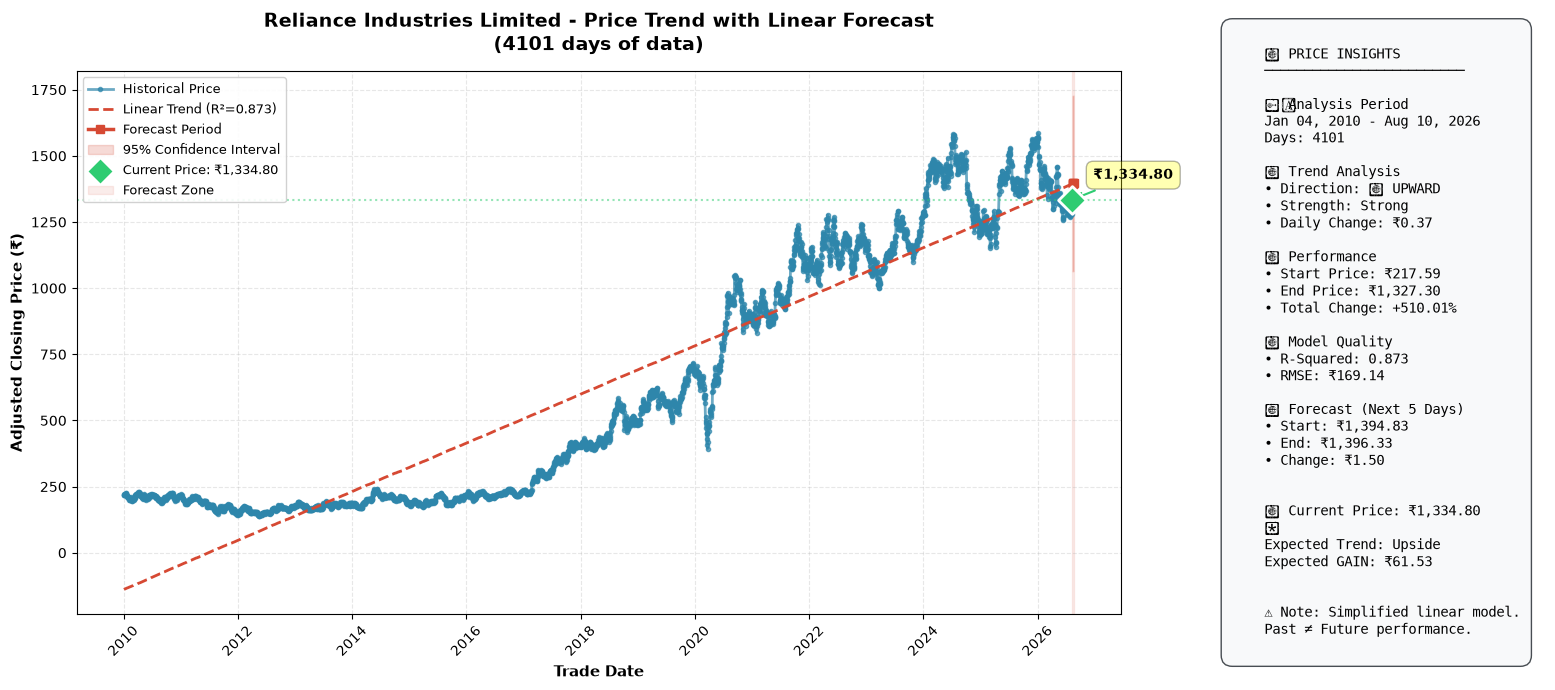


📈 Reliance Industries Limited - Forecast Summary
Data Period: Jan 04, 2010 to Aug 10, 2026
Data Points: 4101
Price Change: +510.01% (₹+1,109.71)
Current Price: ₹1,334.80
Next 5 days forecast: ₹1,396.33
Expected GAIN: ₹61.53
Model R²: 0.873 (Good)



In [24]:
# Then run the chart:
future_prices, r2, rmse = create_stock_forecast_chart(stock_data, todays_data, stock_name)

In [19]:
# Determine forecast direction
get_direction = "up" if coefficients[0] > 0 else "down"
print(f"The forecasted trend for {stock_name} is: {get_direction}")

The forecasted trend for Reliance Industries Limited is: down


In [21]:
current_price = stock_data['adj_close'].iloc[-1]
forecasted_price = forecast_line[-1]

In [43]:
print(current_price, forecasted_price)

5219.0 5655.759172176308


In [22]:

get_trend = calculate_price_status(current_price, forecasted_price, discount_threshold=1.1, precision=2)

In [67]:
# get_trend = "premium" if current_price > forecasted_price and current_price < 1.1 * forecasted_price else "at par" if current_price == forecasted_price else "discount"
# print(f"The current price is at a {get_trend} compared to the forecasted price.")

In [68]:
# # Filter data for Krishna Institute of Medical Sciences Limited
# result_df = price_df[price_df['stock_name'] == stock_name].copy()

# # Ensure date column is datetime type
# result_df['date'] = pd.to_datetime(result_df['date'])

# # Sort by date to ensure chronological order
# result_df = result_df.sort_values('date')

# # Create a DataFrame with date as index for easier lookup
# price_series = result_df.set_index('date')['closing_price']

# # Get today's date and the earliest date in your dataset
# today = datetime.now()
# earliest_date = result_df['date'].min()
# latest_date = result_df['date'].max()
# latest_price = result_df.iloc[-1]['closing_price']  # Get the latest price

# # Calculate how many years of data we have
# years_of_data = today.year - earliest_date.year

# # Create lists to store results - starting with latest date
# years_back_list = ['Latest']  # Start with 'Latest' for current price
# lookup_dates = [latest_date]
# closing_prices = [latest_price]
# target_dates_list = [today]
# days_differences = [0]


In [23]:
data_dict = prepare_stock_data(
    price_df=stock_data,
    stock_name=stock_name,
    date_col='trade_date',
    price_col='adj_close',
    name_col='stock_name')

In [70]:
# # Get prices for each year back until we run out of data
# for years_back in range(1, data_dict['years_of_data'] + 2):  # +2 to include partial years
#     # Calculate the target date (years back from today)
#     target_date = data_dict['today'] - timedelta(days=365 * years_back)
    
#     # Check if target date is before earliest date in dataset
#     if target_date < data_dict['earliest_date']:
#         print(f"\nStopping at {years_back-1} years back. Target date {target_date.date()} is before earliest data ({data_dict['earliest_date'].date()})")
#         break
    
#     # Find the closest available date and price
#     actual_date, price, days_diff = find_closest_date(target_date, data_dict['price_series'])
    
#     if actual_date is not None and price is not None:
#         data_dict['years_back_list'].append(years_back)
#         data_dict['target_dates_list'].append(target_date)
#         data_dict['lookup_dates'].append(actual_date)
#         data_dict['closing_prices'].append(price)
#         data_dict['days_differences'].append(days_diff)
#     else:
#         print(f"No data found for {years_back} years back ({target_date.date()})")

# # Create the result DataFrame
# if data_dict['years_back_list']:  # Check if we found any data
#     result_df = pd.DataFrame({
#         'Years Back': data_dict['years_back_list'],
#         'Target Date': data_dict['target_dates_list'],
#         'Actual Date': data_dict['lookup_dates'],
#         'Closing Price': data_dict['closing_prices'],
#         'Days Difference': data_dict['days_differences']
#     })
    
#     # Create simplified version with just Years Back, Actual Date, and Closing Price
#     simplified_df = result_df[['Years Back', 'Actual Date', 'Closing Price']].rename(
#         columns={'Actual Date': 'lookup_date', 'Closing Price': 'Closing price'}
#     )
    
    # print(f"\nLatest available data point: {data_dict['latest_date'].date()} - ₹{data_dict['latest_price']}")

In [24]:
# Call the function
result_df, simplified_df = get_historical_prices(data_dict)

if result_df is not None:
    print(f"Found {len(result_df)} years of historical prices")
    print(simplified_df.head())


Stopping at 0 years back. Target date 2025-08-12 is before earliest data (2026-01-01)
Found 1 years of historical prices
  Years Back lookup_date  Closing price
0     Latest  2026-08-07    1334.800049


In [25]:
print(simplified_df)

  Years Back lookup_date  Closing price
0     Latest  2026-08-07    1334.800049


In [26]:
# Calculate the returns
simplified_df = calculate_returns(simplified_df)

In [27]:
print(simplified_df)

  Years Back lookup_date  Closing price ROI(in pct)
0     Latest  2026-08-07    1334.800049           -


In [28]:
# Convert ROI(in pct) strings like '26%' or '-' to numeric floats (percent)
roi_numeric = pd.to_numeric(
	simplified_df['ROI(in pct)'].astype(str).str.rstrip('%').replace({'-': np.nan, '': np.nan})
)
median_return = np.nanmedian(roi_numeric)
print(f"\nMedian Return (in pct): {median_return}")
                           


Median Return (in pct): nan


In [29]:
# Add a new key-value pair
stock_metadata['median_return'] = float(median_return)
stock_metadata['current_return'] = float(simplified_df[simplified_df['Years Back']=='Latest']['ROI(in pct)'].values[0])
stock_metadata['direction'] = get_direction
stock_metadata['trend'] = get_trend

ValueError: could not convert string to float: '-'

In [77]:
stock_metadata

{'stock_name': 'Affle 3i Limited',
 'median_return': 20.0,
 'current_return': 18.0,
 'direction': 'up',
 'trend': 'discount'}